In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://realpython.github.io/fake-jobs/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

jobs = []

for card in soup.find_all("div", class_="card-content"):
    title = card.find("h2", class_="title").text.strip()
    company = card.find("h3", class_="company").text.strip()
    location = card.find("p", class_="location").text.strip()
    description = card.find("div", class_="content").text.strip()

    jobs.append([title, company, location, description])

df = pd.DataFrame(jobs, columns=["Title", "Company", "Location", "Description"])

df.to_csv("jobs_data.csv", index=False)

print("Scraping completed.")
df.head()

Scraping completed.


,Title,Company,Location,Description
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA","Stewartbury, AA\n \n\n2021-04-08"
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA","Christopherville, AA\n \n\n2021-04-08"
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA","Port Ericaburgh, AA\n \n\n2021-04-08"
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP","East Seanview, AP\n \n\n2021-04-08"
4,Product manager,Ramirez Inc,"North Jamieview, AP","North Jamieview, AP\n \n\n2021-04-08"


In [ ]:
df["Description_Length"] = df["Description"].apply(lambda x: len(x))

df["Remote"] = df["Location"].apply(lambda x: 1 if "remote" in x.lower() else 0)

df.head()

,Title,Company,Location,Description,Description_Length,Remote
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA","Stewartbury, AA\n \n\n2021-04-08",34,0
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA","Christopherville, AA\n \n\n2021-04-08",39,0
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA","Port Ericaburgh, AA\n \n\n2021-04-08",38,0
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP","East Seanview, AP\n \n\n2021-04-08",36,0
4,Product manager,Ramirez Inc,"North Jamieview, AP","North Jamieview, AP\n \n\n2021-04-08",38,0


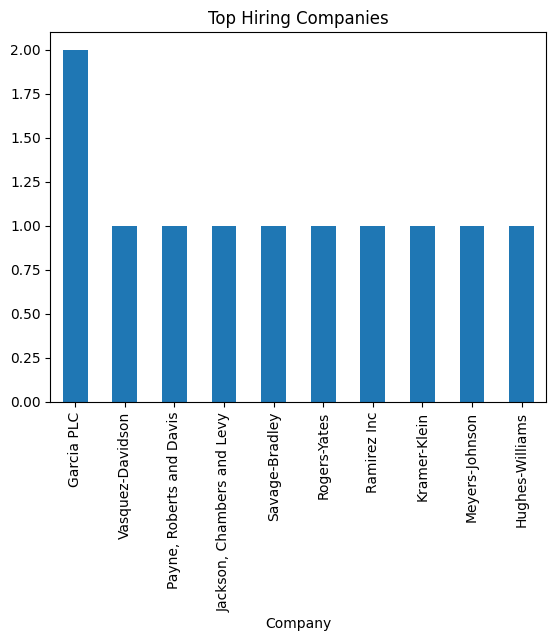

In [ ]:
import matplotlib.pyplot as plt

df["Company"].value_counts().head(10).plot(kind="bar")
plt.title("Top Hiring Companies")
plt.xticks(rotation=90)
plt.show()

MACHINE LEARNING


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

# Ensure no null values
df["Description"] = df["Description"].fillna("")

# Create Remote column if not exists
if "Remote" not in df.columns:
    df["Remote"] = df["Location"].apply(lambda x: 1 if "remote" in x.lower() else 0)

print("Class Distribution:")
print(df["Remote"].value_counts())

X = df["Description"]
y = df["Remote"]

vectorizer = TfidfVectorizer(stop_words="english")
X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.3, random_state=42
)

# Check if y_train has at least two classes
if len(y_train.unique()) < 2:
    print("Cannot train the model: the target variable 'Remote' has only one class in the training set.")
    print("Please ensure your dataset contains at least two classes (e.g., both remote and non-remote jobs) for classification.")
else:
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))


Class Distribution:
Remote
0    100
Name: count, dtype: int64
Cannot train the model: the target variable 'Remote' has only one class in the training set.
Please ensure your dataset contains at least two classes (e.g., both remote and non-remote jobs) for classification.


In [ ]:
from google.colab import files
files.download("jobs_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Re-initialize df (code from BxLbft4wyGvh)
url = "https://realpython.github.io/fake-jobs/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

jobs = []

for card in soup.find_all("div", class_="card-content"):
    title = card.find("h2", class_="title").text.strip()
    company = card.find("h3", class_="company").text.strip()
    location = card.find("p", class_="location").text.strip()
    description = card.find("div", class_="content").text.strip()

    jobs.append([title, company, location, description])

df = pd.DataFrame(jobs, columns=["Title", "Company", "Location", "Description"])

# Re-create Description_Length column (code from s3PCm8iMyJs6)
df["Description_Length"] = df["Description"].apply(lambda x: len(x))

# Original code for the current cell
median_description_length = df['Description_Length'].median()
df['Is_Long_Description'] = df['Description_Length'].apply(lambda x: 1 if x > median_description_length else 0)

print("DataFrame with new 'Is_Long_Description' column:")
df.head()

print("\nValue counts for 'Is_Long_Description':")
print(df['Is_Long_Description'].value_counts())

DataFrame with new 'Is_Long_Description' column:

Value counts for 'Is_Long_Description':
Is_Long_Description
0    61
1    39
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['Description']
y = df['Is_Long_Description']

vectorizer = TfidfVectorizer(stop_words='english')
X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.3, random_state=42)

print("Data preparation complete. Shapes of the split data:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data preparation complete. Shapes of the split data:
X_train shape: (70, 113)
X_test shape: (30, 113)
y_train shape: (70,)
y_test shape: (30,)


## Train and Evaluate Logistic Regression

### Subtask:
Train a Logistic Regression model with the prepared data and evaluate its performance using accuracy score.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Instantiate Logistic Regression model
model_lr = LogisticRegression(max_iter=1000)

# Train the model
model_lr.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = model_lr.predict(X_test)

# Calculate and print the accuracy score
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Model Accuracy: {accuracy_lr:.4f}")

Logistic Regression Model Accuracy: 0.7333


## Train and Evaluate K-Nearest Neighbors

### Subtask:
Train a K-Nearest Neighbors (KNN) model with the prepared data and evaluate its performance using accuracy score.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Instantiate KNN model
# A common practice is to start with an odd number for n_neighbors, e.g., 5
model_knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
model_knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = model_knn.predict(X_test)

# Calculate and print the accuracy score
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"K-Nearest Neighbors Model Accuracy: {accuracy_knn:.4f}")

K-Nearest Neighbors Model Accuracy: 0.6667


## Train and Evaluate Support Vector Machine

### Subtask:
Train a Support Vector Machine (SVM) model with the prepared data and evaluate its performance using accuracy score.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Instantiate SVM model
model_svm = SVC(random_state=42)

# Train the model
model_svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = model_svm.predict(X_test)

# Calculate and print the accuracy score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Support Vector Machine Model Accuracy: {accuracy_svm:.4f}")

Support Vector Machine Model Accuracy: 0.7000


## Hyperparameter Tuning for Logistic Regression

### Subtask:
Perform hyperparameter tuning for the Logistic Regression model using GridSearchCV to find the best parameters and evaluate the model with the best parameters.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'] # 'lbfgs' works well for multiclass, 'liblinear' for small datasets
}

# Instantiate Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Instantiate GridSearchCV
grid_search_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best Parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best Cross-Validation Accuracy for Logistic Regression: {grid_search_lr.best_score_:.4f}")

# Evaluate the model with the best parameters on the test set
best_lr_model = grid_search_lr.best_estimator_
y_pred_lr_tuned = best_lr_model.predict(X_test)
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
print(f"Tuned Logistic Regression Model Accuracy on Test Set: {accuracy_lr_tuned:.4f}")

Best Parameters for Logistic Regression: {'C': 10, 'solver': 'liblinear'}
Best Cross-Validation Accuracy for Logistic Regression: 0.6857
Tuned Logistic Regression Model Accuracy on Test Set: 0.7333


In [ ]:
import pandas as pd

# Create a dictionary to store model accuracies
model_accuracies = {
    'Model': ['Logistic Regression (Untuned)', 'K-Nearest Neighbors', 'Support Vector Machine', 'Logistic Regression (Tuned)'],
    'Accuracy': [accuracy_lr, accuracy_knn, accuracy_svm, accuracy_lr_tuned]
}

# Create a DataFrame from the dictionary
accuracy_df = pd.DataFrame(model_accuracies)

# Print the summary table
print("\nModel Performance Summary:")
print(accuracy_df)



Model Performance Summary:
                           Model  Accuracy
0  Logistic Regression (Untuned)  0.733333
1            K-Nearest Neighbors  0.666667
2         Support Vector Machine  0.700000
3    Logistic Regression (Tuned)  0.733333
